# **This file generates results and figures for the term paper in Dynamic Programming**

## By: Konrad Juel Thide & Theodor Justus Bock

### Load packages and model class

In [11]:
%load_ext autoreload
%autoreload 2
from tools_final import EnergyStorageModel
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from collections import defaultdict
import matplotlib.colors as mcolors
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **Methodology**

## **Figure 1:** Policy Function Iteration vs. Value Function Iteration

... simulating price data
Simulating price series...

=== Running for β = 0.990 ===
Starting Vectorized Value Function Iteration...
Converged after 916 iterations.
VFI took 2.32 seconds
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 8.0000
Iter 001: ΔV = 4.060e+00, Δπ = 16.0000
Iter 002: ΔV = 4.274e+00, Δπ = 8.2581
Iter 003: ΔV = 3.014e+00, Δπ = 5.6774
Iter 004: ΔV = 1.441e+00, Δπ = 2.3226
Iter 005: ΔV = 5.654e-01, Δπ = 1.2903
Iter 006: ΔV = 1.258e-01, Δπ = 0.5161
Iter 007: ΔV = 2.116e-02, Δπ = 0.2581
Iter 008: ΔV = 1.172e-03, Δπ = 0.2581
Iter 009: ΔV = 3.118e-05, Δπ = 0.0000
Converged after 10 iterations.
PFI took 0.58 seconds

=== Running for β = 0.991 ===
Starting Vectorized Value Function Iteration...
Converged after 1052 iterations.
VFI took 2.65 seconds
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.148e+02, Δπ = 8.0000
Iter 001: ΔV = 4.069e+00, Δπ = 16.0000
Iter 002: ΔV = 4.366e+00, Δπ = 8.2581
Iter 003: ΔV = 3.239e+00, Δπ = 5.6774
Iter 004: ΔV 

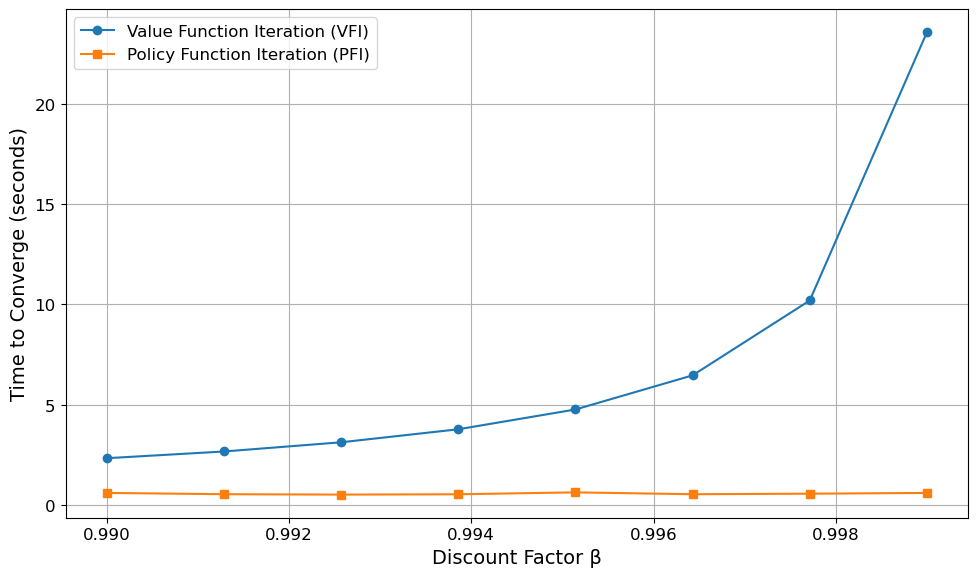

In [2]:
betas = np.linspace(0.990, 0.999, 8)  # avoid beta=1
vfi_times = []
pfi_times = []

model = EnergyStorageModel(eta_charge=0.95, 
                                eta_discharge=0.95, 
                                a_bar = 8,
                                max_battery_capacity=32,
                                num_storage_levels=51,
                                num_actions=63,
                                num_price_levels=30,
                                tolerance = 1e-4,
                                max_iteration=20_000,
                                simulate_prices = True,
                                risk_averse=True,
                                risk_parameter=0.01)

for beta in betas:
    print(f"\n=== Running for β = {beta:.3f} ===")
    model.beta = beta

    # Time VFI
    start = time.time()
    V_vfi, P_vfi = model.vfi_vec()
    vfi_elapsed = time.time() - start
    vfi_times.append(vfi_elapsed)
    print(f"VFI took {vfi_elapsed:.2f} seconds")

    # Time PFI
    start = time.time()
    V_pfi, P_pfi = model.pfi_vec()
    pfi_elapsed = time.time() - start
    pfi_times.append(pfi_elapsed)
    print(f"PFI took {pfi_elapsed:.2f} seconds")

plt.rcParams.update({
    'font.size': 14,            # Global font size
    'axes.titlesize': 16,       # Title font
    'axes.labelsize': 14,       # Axis labels
    'xtick.labelsize': 12,      # X tick labels
    'ytick.labelsize': 12,      # Y tick labels
    'legend.fontsize': 12       # Legend text
})

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(betas, vfi_times, label='Value Function Iteration (VFI)', marker='o')
plt.plot(betas, pfi_times, label='Policy Function Iteration (PFI)', marker='s')
plt.xlabel('Discount Factor β')
plt.ylabel('Time to Converge (seconds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Model dynamics in a stylized environment** 

## **Figure 2:** Policy function heatmap for the risk averse and risk neutral operator


--- Running Model with risk_averse = False ---
... simulating price data
Simulating price series...
.... Starting Policy Function Iteration
Iter 000: ΔV = 0.000e+00, Δπ = 10.0000
Iter 001: ΔV = 5.923e+03, Δπ = 20.0000
Iter 002: ΔV = 4.273e+03, Δπ = 19.9800
Iter 003: ΔV = 1.458e+03, Δπ = 9.9900
Iter 004: ΔV = 2.388e+02, Δπ = 9.9700
Iter 005: ΔV = 4.285e+00, Δπ = 1.9820
Iter 006: ΔV = 8.458e-02, Δπ = 0.0000
Iter 007: ΔV = 0.000e+00, Δπ = 0.0000
Converged after 8 iterations.

--- Running Model with risk_averse = True ---
... simulating price data
Simulating price series...
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.319e+00, Δπ = 20.0000
Iter 002: ΔV = 1.930e+00, Δπ = 10.0100
Iter 003: ΔV = 1.015e+00, Δπ = 3.5235
Iter 004: ΔV = 8.443e-02, Δπ = 0.7407
Iter 005: ΔV = 3.014e-03, Δπ = 0.0801
Converged after 6 iterations.


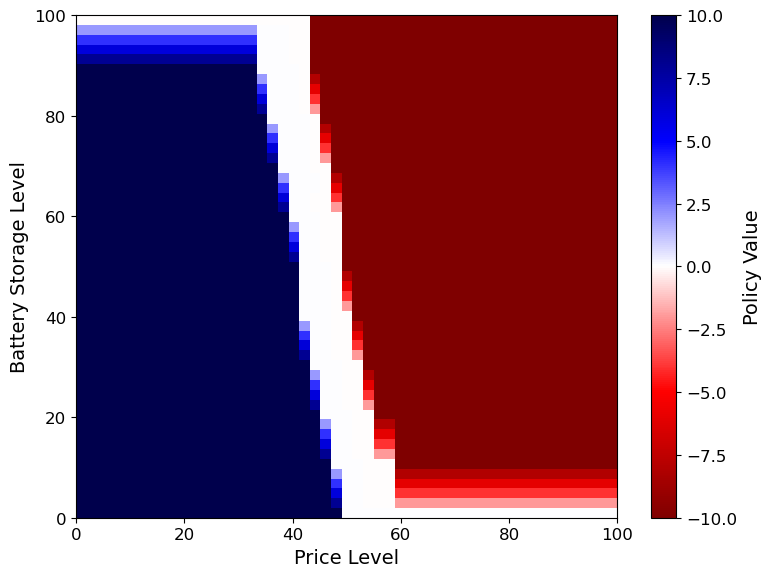

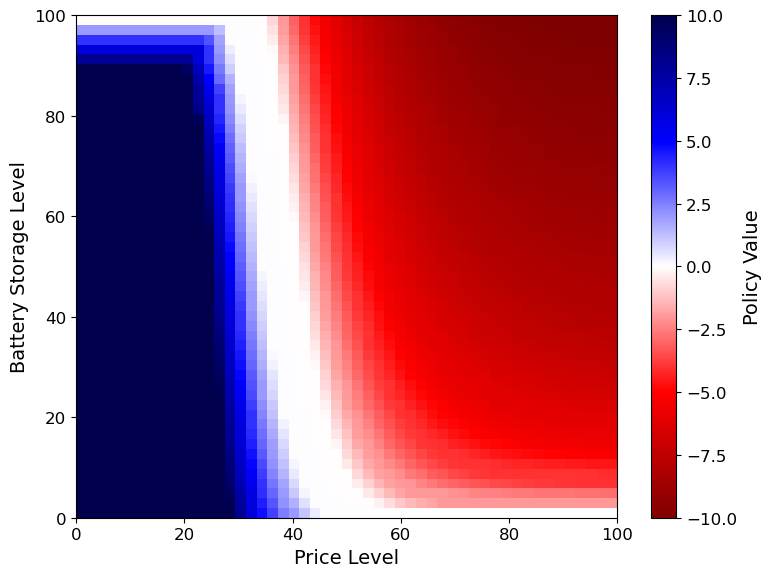

In [3]:
# Define results storage
results = {}

# Loop over both risk settings
for risk_setting in [False, True]:
    print(f"\n--- Running Model with risk_averse = {risk_setting} ---")

    # Initialize the model
    model = EnergyStorageModel(eta_charge=0.98, 
                            eta_discharge=0.97, 
                            beta = 0.99,
                            a_bar = 10,
                            max_battery_capacity=100,
                            num_storage_levels=51,
                            num_actions=1000,
                            num_price_levels=51,
                            tolerance = 1e-2,
                            max_iteration=10_000,
                            simulate_prices = True,
                            mean_reversion= 0.3,
                            p_variance = 100,
                            risk_averse=risk_setting,
                            risk_parameter=0.001)

    # Solve value function and get policy
    V, P = model.pfi_vec()

    # Simulate using the policy
    battery_storage_sim, profit_sim, action_sim = model.simulate(policy=P)

    # Store results
    results[risk_setting] = {
        'model': model,
        'V': V,
        'policy': P,
        'storage': battery_storage_sim,
        'profit': profit_sim,
        'action': action_sim
    }


# Plot policies for Risk-Neutral and Risk-Averse
for risk_setting in [False, True]:
    label = "Risk-Averse" if risk_setting else "Risk-Neutral"
    policy = results[risk_setting]['policy']
    model = results[risk_setting]['model']

    non_zero = policy != 0
    norm = mcolors.TwoSlopeNorm(
        vmin=policy[non_zero].min(),
        vcenter=0,
        vmax=policy[non_zero].max()
    )
    cmap = plt.get_cmap("seismic_r")

    plt.rcParams.update({
        'font.size': 14,            # Global font size
        'axes.titlesize': 16,       # Title font
        'axes.labelsize': 14,       # Axis labels
        'xtick.labelsize': 12,      # X tick labels
        'ytick.labelsize': 12,      # Y tick labels
        'legend.fontsize': 12       # Legend text
    })

    plt.figure(figsize=(8, 6))
    im = plt.imshow(policy, origin='lower', aspect='auto', cmap=cmap, norm=norm,
                    extent=[model.price_grid[0], model.price_grid[-1],
                            model.battery_grid[0], model.battery_grid[-1]])
    plt.xlabel("Price Level")
    plt.ylabel("Battery Storage Level")
    plt.colorbar(im, label="Policy Value")
    plt.tight_layout()
    plt.show()



## **Figure 3:** Simulated operations for the first 100 hours for risk neutral and risk averse operators

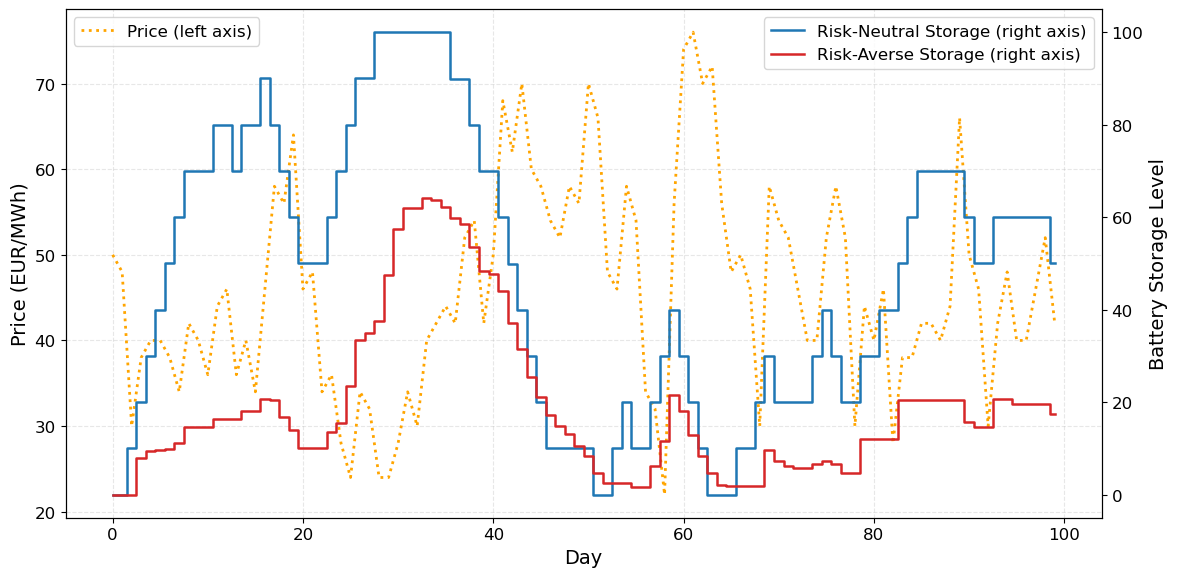

In [4]:
# Define labels and colors
labels = {False: "Risk-Neutral", True: "Risk-Averse"}
colors = {False: "#1f77b4", True: "#d62728"}  # Blue, Red

# --- Create single plot ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Shared x-axis
days = np.arange(100)
prices = results[False]['model'].prices[:100]

# --- Plot price (left y-axis) ---
line_price, = ax1.plot(
    days, prices, linestyle=":", color="orange", linewidth=2,
    label="Price (EUR/MWh)"
)
ax1.set_ylabel("Price (EUR/MWh)")  
ax1.tick_params(axis='y')
ax1.set_xlabel("Day")
ax1.grid(True, linestyle="--", alpha=0.3)

# --- Plot storage (right y-axis) ---
ax1b = ax1.twinx()
storage_lines = []
for risk_setting in [False, True]:
    storage = results[risk_setting]['storage'][:100]
    line, = ax1b.step(
        days, storage, where='mid',
        label=f"{labels[risk_setting]} Storage (right axis)",
        color=colors[risk_setting], linewidth=1.8
    )
    storage_lines.append(line)

ax1b.set_ylabel("Battery Storage Level")
ax1b.tick_params(axis='y', labelcolor="black")

# Separate legends
ax1.legend([line_price], ["Price (left axis)"], loc="upper left")
ax1b.legend(storage_lines, [l.get_label() for l in storage_lines], loc="upper right")
plt.tight_layout()
plt.show()


## **Figure 4a:** Profit sensitivity to technological advancement

... simulating price data
Simulating price series...
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.319e+00, Δπ = 20.0000
Iter 002: ΔV = 1.930e+00, Δπ = 10.0100
Iter 003: ΔV = 1.015e+00, Δπ = 3.5235
Iter 004: ΔV = 8.443e-02, Δπ = 0.7407
Iter 005: ΔV = 3.014e-03, Δπ = 0.0801
Converged after 6 iterations.
Baseline profit = 137976.78
Running: η_c=0.80, η_d=0.80, σ=0.00000
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 3.712e+00, Δπ = 20.0000
Iter 002: ΔV = 1.344e+00, Δπ = 10.0100
Iter 003: ΔV = 4.903e-01, Δπ = 4.5445
Iter 004: ΔV = 6.718e-02, Δπ = 1.5415
Iter 005: ΔV = 4.857e-03, Δπ = 0.0801
Converged after 6 iterations.
Running: η_c=0.80, η_d=0.80, σ=0.00500
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 3.643e+00, Δπ = 20.0000
Iter 002: ΔV = 1.184e+00, Δπ = 9.9900
Iter 003: ΔV = 3.991e-01, Δπ = 4.4845
Iter 004: ΔV = 3.954e-02, Δπ = 1.6416
Iter 00

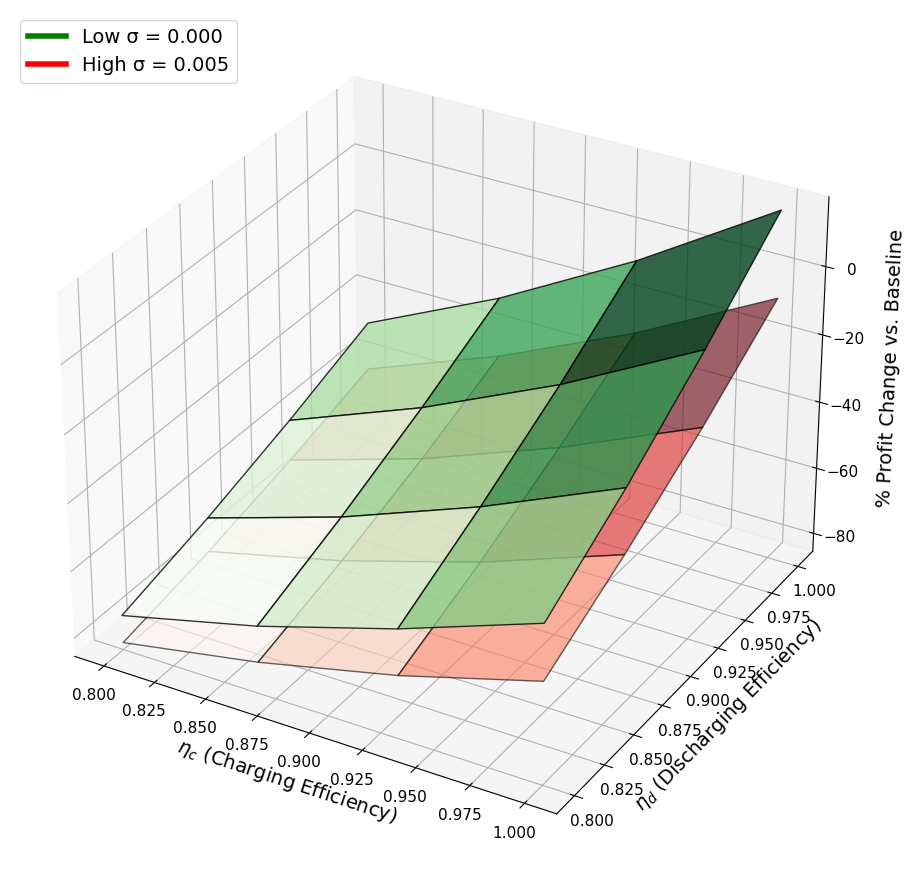

In [5]:
# --- STEP 1: Run baseline model ---
baseline_model = EnergyStorageModel(eta_charge=0.98, 
                           eta_discharge=0.97, 
                           beta = 0.99,
                           a_bar = 10,
                           max_battery_capacity=100,
                           num_storage_levels=51,
                           num_actions=1000,
                           num_price_levels=51,
                           tolerance = 1e-2,
                           max_iteration=10_000,
                           simulate_prices = True,
                           mean_reversion= 0.3,
                           p_variance = 100,
                           risk_averse=True,
                           risk_parameter=0.001)

V_base, P_base = baseline_model.pfi_vec()
_, profit_base, _ = baseline_model.simulate(policy=P_base)
baseline_profit = profit_base[-1]
print(f"Baseline profit = {baseline_profit:.2f}")


# --- Step 2: Grid simulations ---
N = 4
eta_vals = np.linspace(0.8, 1, N)
sigma_vals = [0.0, 0.005]

tech_policy = {}

for eta_c in eta_vals:
    for eta_d in eta_vals:
        for sigma in sigma_vals:
            print(f"Running: η_c={eta_c:.2f}, η_d={eta_d:.2f}, σ={sigma:.5f}")
            baseline_model.eta_charge = eta_c
            baseline_model.eta_discharge = eta_d
            baseline_model.sigma = sigma

            _, P = baseline_model.pfi_vec()
            _, profit_sim, _ = baseline_model.simulate(policy=P)
            tech_policy[(eta_c, eta_d, sigma)] = profit_sim[-1]

# --- Step 3: Build % change arrays ---
eta_grid, discharge_grid = np.meshgrid(eta_vals, eta_vals)
get_z = lambda σ: np.array([
    [(tech_policy[(ηc, ηd, σ)] - baseline_profit) / baseline_profit * 100 for ηd in eta_vals]
    for ηc in eta_vals
])
z_low, z_high = get_z(sigma_vals[0]), get_z(sigma_vals[1])

# --- Step 4: Plot ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(eta_grid, discharge_grid, z_low, cmap='Greens', alpha=0.8, edgecolor='k')
ax.plot_surface(eta_grid, discharge_grid, z_high, cmap='Reds', alpha=0.6, edgecolor='k')

ax.set_xlabel(r'$\eta_c$ (Charging Efficiency)', fontsize=14)
ax.set_ylabel(r'$\eta_d$ (Discharging Efficiency)', fontsize=14)
ax.set_zlabel('% Profit Change vs. Baseline', labelpad=10, fontsize=14)

# Create legend handles
legend_elements = [
    Line2D([0], [0], color='green', lw=4, label=f'Low σ = {sigma_vals[0]:.3f}'),
    Line2D([0], [0], color='red', lw=4, label=f'High σ = {sigma_vals[1]:.3f}')
]
ax.tick_params(axis='both', labelsize=11)
# Corrected legend line
ax.legend(handles=legend_elements, loc='upper left',fontsize=14)
plt.tight_layout()
plt.show()

## **Figure 4b:** Illustrating mechanical vs. behaviroal effect from increase in efficiency

... simulating price data
Simulating price series...
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.319e+00, Δπ = 20.0000
Iter 002: ΔV = 1.930e+00, Δπ = 10.0100
Iter 003: ΔV = 1.015e+00, Δπ = 3.5235
Iter 004: ΔV = 8.443e-02, Δπ = 0.7407
Iter 005: ΔV = 3.014e-03, Δπ = 0.0801
Converged after 6 iterations.
Running for eta_discharge = 0.970
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.319e+00, Δπ = 20.0000
Iter 002: ΔV = 1.930e+00, Δπ = 10.0100
Iter 003: ΔV = 1.015e+00, Δπ = 3.5235
Iter 004: ΔV = 8.443e-02, Δπ = 0.7407
Iter 005: ΔV = 3.014e-03, Δπ = 0.0801
Converged after 6 iterations.
Running for eta_discharge = 0.971
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.323e+00, Δπ = 20.0000
Iter 002: ΔV = 1.935e+00, Δπ = 10.0100
Iter 003: ΔV = 1.017e+00, Δπ = 3.5235
Iter 004: ΔV = 8.524e-02, Δπ = 0.7407
Iter 005: ΔV = 3.153e-03, Δπ = 0.0801
Conver

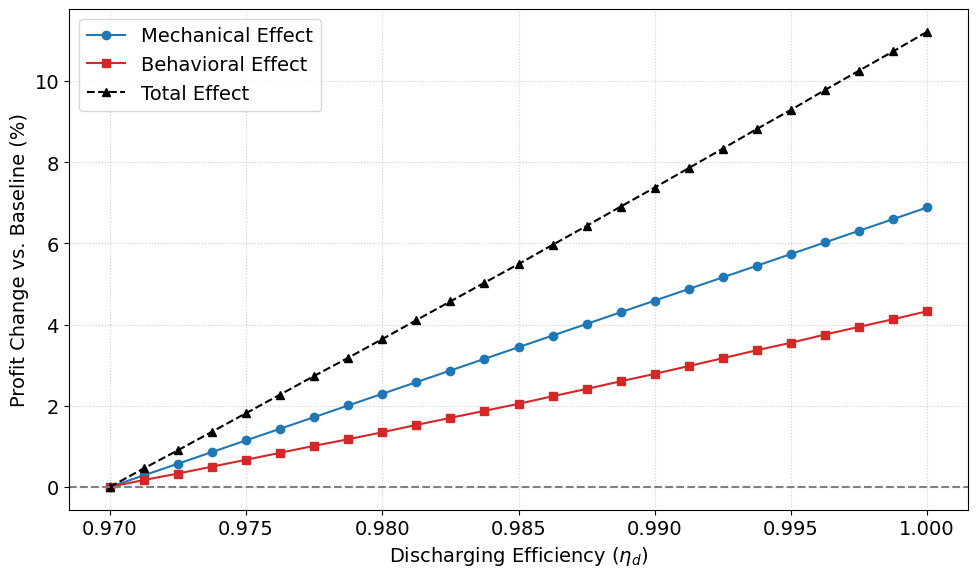

In [6]:
# --- STEP 1: Run baseline model ---
baseline_model = EnergyStorageModel(eta_charge=0.98, 
                           eta_discharge=0.97, 
                           beta = 0.99,
                           a_bar = 10,
                           max_battery_capacity=100,
                           num_storage_levels=51,
                           num_actions=1000,
                           num_price_levels=51,
                           tolerance = 1e-2,
                           max_iteration=10_000,
                           simulate_prices = True,
                           mean_reversion= 0.3,
                           p_variance = 100,
                           risk_averse=True,
                           risk_parameter=0.001)

V_base, P_base = baseline_model.pfi_vec()
_, profit_base, _ = baseline_model.simulate(policy=P_base)
baseline_profit = profit_base[-1]

# --- STEP 2: Loop over eta_d using the same model object ---
N = 25
eta_discharge_vals = np.linspace(0.97, 1.0, N)
results = {"eta_discharge": [], "mechanical_profit": [], "behavioral_profit": [], "total_profit": []}

for eta_d in eta_discharge_vals:
    print(f"Running for eta_discharge = {eta_d:.3f}")
    baseline_model.eta_discharge = eta_d

    # Mechanical effect (simulate with baseline policy)
    _, profit_mech, _ = baseline_model.simulate(policy=P_base)
    mechanical_profit = profit_mech[-1]

    # Behavioral effect (new optimal policy)
    _, P_new = baseline_model.pfi_vec()
    _, profit_total, _ = baseline_model.simulate(policy=P_new)
    total_profit = profit_total[-1]
    behavioral_profit = total_profit - mechanical_profit

    # Store results
    results["eta_discharge"].append(eta_d)
    results["mechanical_profit"].append(mechanical_profit)
    results["behavioral_profit"].append(behavioral_profit)
    results["total_profit"].append(total_profit)

# --- STEP 3: Plot ---

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

eta_discharge_vals = np.array(results["eta_discharge"])
mechanical = (np.array(results["mechanical_profit"]) - baseline_profit) / baseline_profit * 100
behavioral = np.array(results["behavioral_profit"]) / baseline_profit * 100
total = (np.array(results["total_profit"]) - baseline_profit) / baseline_profit * 100

plt.figure(figsize=(10, 6))


effects = {
    "Mechanical Effect": (mechanical, "#1f77b4", 'o'),
    "Behavioral Effect": (behavioral, "#d62728", 's'),
    "Total Effect": (total, "black", '^')
}

for label, (data, color, marker) in effects.items():
    plt.plot(eta_discharge_vals, data, label=label, color=color, marker=marker,
             linestyle='--' if label == "Total Effect" else '-')

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel(r"Discharging Efficiency ($\eta_d$)")
plt.ylabel("Profit Change vs. Baseline (%)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## **Figure 5:** Model sensitivity to changes in price dynamics

... simulating price data
Simulating price series...
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.378e+00, Δπ = 20.0000
Iter 002: ΔV = 1.351e+00, Δπ = 10.0100
Iter 003: ΔV = 1.846e-01, Δπ = 5.9459
Iter 004: ΔV = 4.231e-02, Δπ = 2.0220
Iter 005: ΔV = 4.342e-03, Δπ = 0.2202
Converged after 6 iterations.
... simulating price data
Simulating price series...
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.358e+00, Δπ = 20.0000
Iter 002: ΔV = 1.529e+00, Δπ = 10.0100
Iter 003: ΔV = 4.892e-01, Δπ = 4.6847
Iter 004: ΔV = 9.432e-02, Δπ = 0.8809
Iter 005: ΔV = 5.075e-03, Δπ = 0.1201
Converged after 6 iterations.
... simulating price data
Simulating price series...
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+02, Δπ = 10.0000
Iter 001: ΔV = 4.319e+00, Δπ = 20.0000
Iter 002: ΔV = 1.930e+00, Δπ = 10.0100
Iter 003: ΔV = 1.015e+00, Δπ = 3.5235
Iter 004: ΔV = 8.443e-02, Δπ = 0.7407
Iter 0

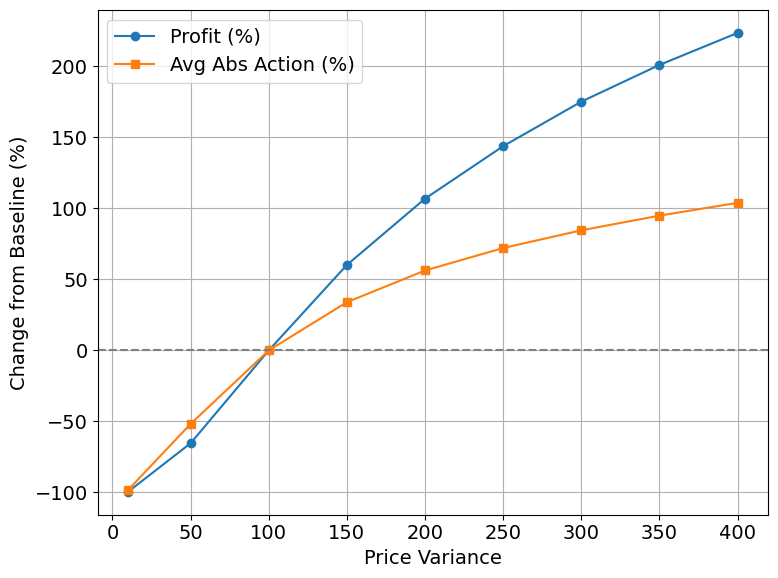

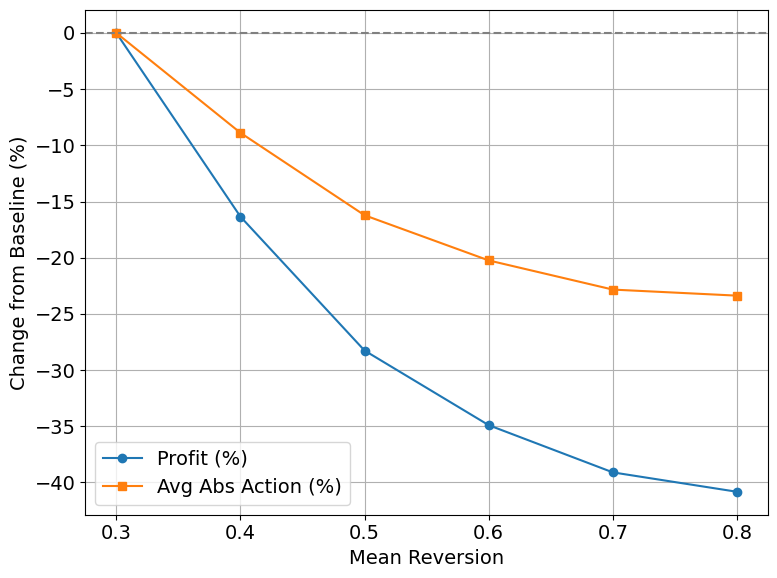

In [7]:
# Parameter sets
price_variances = [10, 50, 100, 150,  200, 250, 300, 350, 400]
mean_reversions = [0.3, 0.4, 0.5, 0.6,  0.7, 0.8]

fixed_mean_reversion = 0.3
fixed_price_variance = 100

# Containers
profits_vs_variance = []
actions_vs_variance = []
profits_vs_reversion = []
actions_vs_reversion = []

# ---- Sweep over Price Variance ----
for pv in price_variances:
    model = EnergyStorageModel(eta_charge=0.98, 
                            eta_discharge=0.97, 
                            beta = 0.99,
                            a_bar = 10,
                            max_battery_capacity=100,
                            num_storage_levels=51,
                            num_actions=1000,
                            num_price_levels=51,
                            tolerance = 1e-2,
                            max_iteration=10_000,
                            simulate_prices = True,
                            mean_reversion= fixed_mean_reversion,
                            p_variance = pv,
                            risk_averse=True,
                            risk_parameter=0.001)
    
    V, P = model.pfi_vec()
    _, profit_sim, action_sim = model.simulate(policy=P)

    profit = profit_sim[-1] - profit_sim[0]
    avg_action = np.mean(np.abs(action_sim))

    profits_vs_variance.append(profit)
    actions_vs_variance.append(avg_action)

# ---- Sweep over Mean Reversion ----
for mr in mean_reversions:
    model = EnergyStorageModel(eta_charge=0.98, 
                            eta_discharge=0.97, 
                            beta = 0.99,
                            a_bar = 10,
                            max_battery_capacity=100,
                            num_storage_levels=51,
                            num_actions=1000,
                            num_price_levels=51,
                            tolerance = 1e-2,
                            max_iteration=10_000,
                            simulate_prices = True,
                            mean_reversion= mr,
                            p_variance = fixed_price_variance,
                            risk_averse=True,
                            risk_parameter=0.001)
    V, P = model.pfi_vec()
    _, profit_sim, action_sim = model.simulate(policy=P)

    profit = profit_sim[-1] - profit_sim[0]
    avg_action = np.mean(np.abs(action_sim))

    profits_vs_reversion.append(profit)
    actions_vs_reversion.append(avg_action)

# ---- Convert to % change from baseline ----
baseline_profit_variance = profits_vs_variance[price_variances.index(100)]
baseline_action_variance = actions_vs_variance[price_variances.index(100)]

baseline_profit_reversion = profits_vs_reversion[mean_reversions.index(0.3)]
baseline_action_reversion = actions_vs_reversion[mean_reversions.index(0.3)]

profits_vs_variance_pct = [(x / baseline_profit_variance - 1) * 100 for x in profits_vs_variance]
actions_vs_variance_pct = [(x / baseline_action_variance - 1) * 100 for x in actions_vs_variance]

profits_vs_reversion_pct = [(x / baseline_profit_reversion - 1) * 100 for x in profits_vs_reversion]
actions_vs_reversion_pct = [(x / baseline_action_reversion - 1) * 100 for x in actions_vs_reversion]

# ---- Plot: Price Variance Sweep ----
plt.figure(figsize=(8, 6))
plt.plot(price_variances, profits_vs_variance_pct, marker='o', label='Profit (%)')
plt.plot(price_variances, actions_vs_variance_pct, marker='s', label='Avg Abs Action (%)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Price Variance")
plt.ylabel("Change from Baseline (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot: Mean Reversion Sweep ----
plt.figure(figsize=(8, 6))
plt.plot(mean_reversions, profits_vs_reversion_pct, marker='o', label='Profit (%)')
plt.plot(mean_reversions, actions_vs_reversion_pct, marker='s', label='Avg Abs Action (%)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Mean Reversion")
plt.ylabel("Change from Baseline (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **Arbitrage in the Danish power market (actual data)**

# **Figure 6:** Price transition probabilities based on actual data

... loading price data


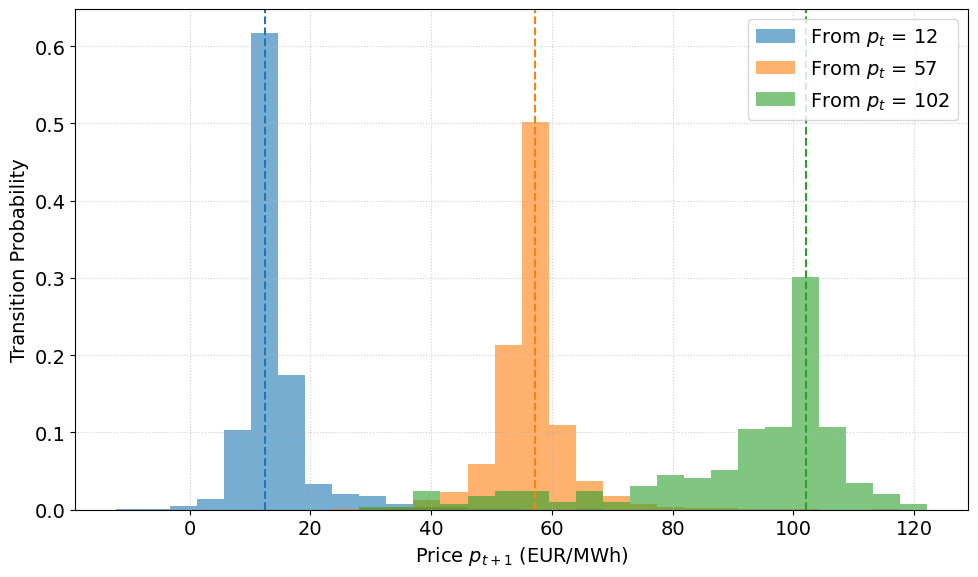

In [8]:
# --- Manually select indices you want to plot ---
selected_indices = [5, 15, 25]  # <-- change these as needed

model = EnergyStorageModel(
        eta_charge=0.98, 
        eta_discharge=0.97, 
        beta=0.99999,
        a_bar=8,
        max_battery_capacity=32,
        num_storage_levels=51,
        num_actions=100,
        num_price_levels=30,
        tolerance=1e-2,
        max_iteration=10_000,
        simulate_prices=False,
        risk_averse=True,
        risk_parameter=0.005)

# Setup
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = [fr"From $p_t$ = {model.price_grid[i]:.0f}" for i in selected_indices]

# Plot
plt.figure(figsize=(10, 6))

for idx, color, label in zip(selected_indices, colors, labels):
    plt.bar(model.price_grid, model.price_transitions[idx],
            width=np.diff(model.price_grid).mean(),  # fill gaps
            alpha=0.6, color=color, label=label, edgecolor='none')
    plt.axvline(model.price_grid[idx], color=color, linestyle='--', linewidth=1.5)

# Formatting
plt.xlabel(r"Price $p_{t+1}$ (EUR/MWh)")
plt.ylabel("Transition Probability")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



# **Figure 7:** Simulated profits in DK1 for various risk preferences

... loading price data
.... Starting Policy Function Iteration
Iter 000: ΔV = 0.000e+00, Δπ = 8.0000
Iter 001: ΔV = 3.535e+04, Δπ = 16.0000
Iter 002: ΔV = 1.361e+05, Δπ = 8.5657
Iter 003: ΔV = 4.048e+05, Δπ = 11.7980
Iter 004: ΔV = 5.011e+04, Δπ = 7.9192
Iter 005: ΔV = 1.354e+04, Δπ = 3.0707
Iter 006: ΔV = 7.341e+02, Δπ = 3.0707
Iter 007: ΔV = 1.429e+02, Δπ = 3.0707
Iter 008: ΔV = 6.275e+01, Δπ = 0.4848
Iter 009: ΔV = 2.902e-01, Δπ = 0.0000
Iter 010: ΔV = 0.000e+00, Δπ = 0.0000
Converged after 11 iterations.
... loading price data
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+05, Δπ = 8.0000
Iter 001: ΔV = 2.654e+02, Δπ = 16.0000
Iter 002: ΔV = 3.045e+02, Δπ = 8.0808
Iter 003: ΔV = 5.101e+02, Δπ = 5.6566
Iter 004: ΔV = 5.453e+02, Δπ = 4.5253
Iter 005: ΔV = 3.359e+02, Δπ = 2.5859
Iter 006: ΔV = 9.434e+01, Δπ = 0.9697
Iter 007: ΔV = 2.254e+01, Δπ = 0.3232
Iter 008: ΔV = 2.526e+00, Δπ = 0.1616
Iter 009: ΔV = 4.093e-02, Δπ = 0.0000
Iter 010: ΔV = 0.000e+00, Δπ = 0.0000
Conv

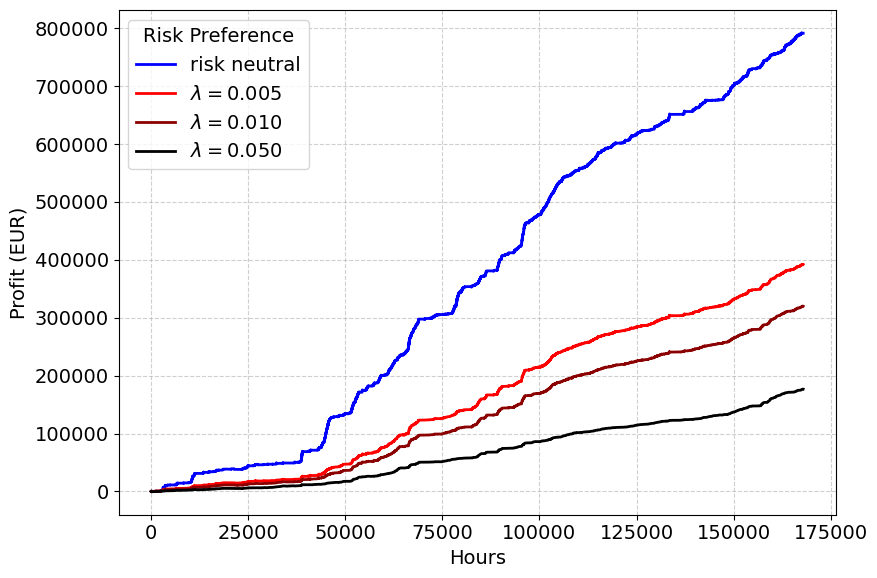

In [9]:
# Define risk aversion levels
risk_params = [0.0, 0.005, 0.01, 0.05]
colors = ['blue', 'red', 'darkred', 'black']
labels = ['risk neutral', r'$\lambda = 0.005$', r'$\lambda = 0.010$', r'$\lambda = 0.050$']
results = {}

# Run model for each risk level
for lam, color, label in zip(risk_params, colors, labels):
    model = EnergyStorageModel(
        eta_charge=0.98, 
        eta_discharge=0.97, 
        beta=0.99999,
        a_bar=8,
        max_battery_capacity=32,
        num_storage_levels=51,
        num_actions=100,
        num_price_levels=30,
        tolerance=1e-2,
        max_iteration=10_000,
        simulate_prices=False,
        risk_averse=(lam > 0),
        risk_parameter=lam
    )

    _, P = model.pfi_vec()
    _, profit_sim, _ = model.simulate(policy=P)
    results[label] = (profit_sim, color)

# --- Plot ---
plt.figure(figsize=(9, 6))
for label, (profit, color) in results.items():
    plt.plot(profit, label=label, color=color, linewidth=2)

plt.xlabel("Hours")
plt.ylabel("Profit (EUR)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Risk Preference")
plt.tight_layout()
plt.show()


# **Figure 8:** Profit sensitivity to increased battery efficiency

... loading price data
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+05, Δπ = 8.0000
Iter 001: ΔV = 2.654e+02, Δπ = 16.0000
Iter 002: ΔV = 3.045e+02, Δπ = 8.0808
Iter 003: ΔV = 5.101e+02, Δπ = 5.6566
Iter 004: ΔV = 5.453e+02, Δπ = 4.5253
Iter 005: ΔV = 3.359e+02, Δπ = 2.5859
Iter 006: ΔV = 9.434e+01, Δπ = 0.9697
Iter 007: ΔV = 2.254e+01, Δπ = 0.3232
Iter 008: ΔV = 2.526e+00, Δπ = 0.1616
Iter 009: ΔV = 4.093e-02, Δπ = 0.0000
Iter 010: ΔV = 0.000e+00, Δπ = 0.0000
Converged after 11 iterations.
Baseline profit = 392161.69
Running: η_c=0.950000, η_d=0.950000
.... Starting Policy Function Iteration
Iter 000: ΔV = 1.000e+05, Δπ = 8.0000
Iter 001: ΔV = 3.315e+02, Δπ = 16.0000
Iter 002: ΔV = 3.337e+02, Δπ = 8.0808
Iter 003: ΔV = 4.698e+02, Δπ = 5.6566
Iter 004: ΔV = 5.133e+02, Δπ = 3.8788
Iter 005: ΔV = 3.278e+02, Δπ = 1.9394
Iter 006: ΔV = 9.295e+01, Δπ = 0.6465
Iter 007: ΔV = 2.162e+01, Δπ = 0.1616
Iter 008: ΔV = 1.699e+00, Δπ = 0.1616
Iter 009: ΔV = 2.999e-02, Δπ = 0.1616
It

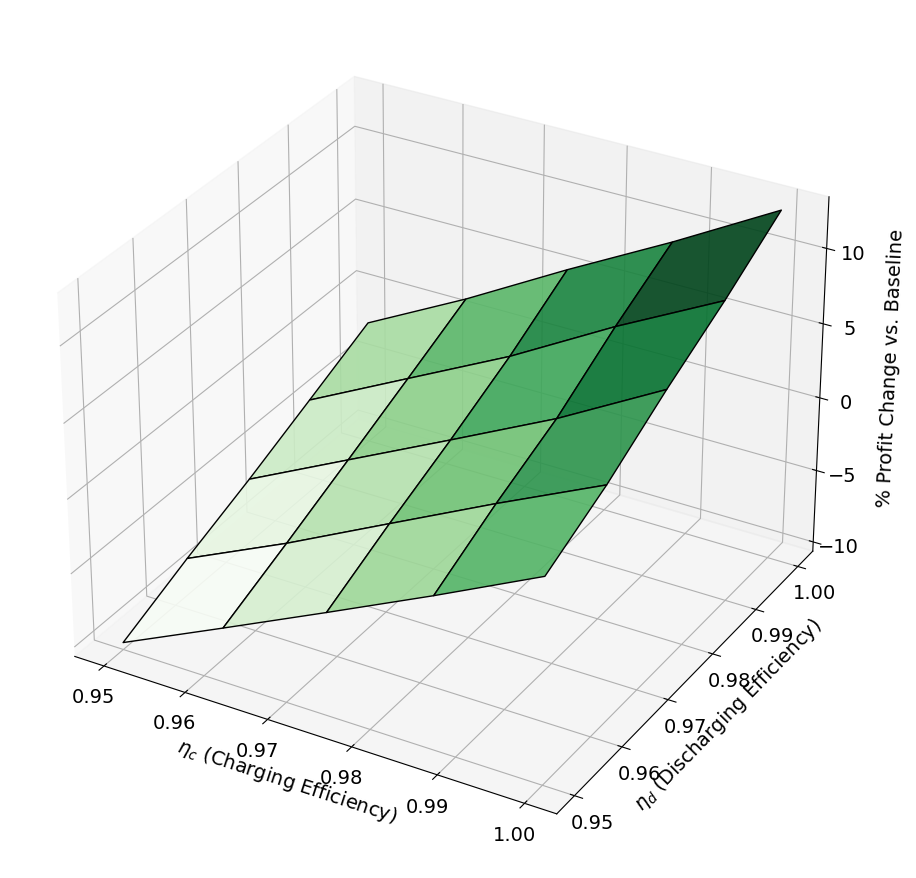

In [10]:
# --- STEP 1: Run baseline model ---
baseline_model_dk1 = EnergyStorageModel(
    eta_charge=0.98, 
    eta_discharge=0.97, 
    beta=0.99999,
    a_bar=8,
    max_battery_capacity=32,
    num_storage_levels=51,
    num_actions=100,
    num_price_levels=30,
    tolerance=1e-2,
    max_iteration=10_000,
    simulate_prices=False,
    risk_averse=True,
    risk_parameter=0.005
)

V_base, P_base = baseline_model_dk1.pfi_vec(dampening=False)
_, profit_base, _ = baseline_model_dk1.simulate(policy=P_base)
baseline_profit = profit_base[-1]
print(f"Baseline profit = {baseline_profit:.2f}")

# --- Step 2: Grid simulations ---
N = 5
eta_vals = np.linspace(0.95, 1, N)


tech_policy = {}

for eta_c in eta_vals:
    for eta_d in eta_vals:
        print(f"Running: η_c={eta_c:.6f}, η_d={eta_d:.6f}")
        baseline_model_dk1.eta_charge = eta_c
        baseline_model_dk1.eta_discharge = eta_d

        _, P = baseline_model_dk1.pfi_vec(dampening=True)
        _, profit_sim, _ = baseline_model_dk1.simulate(policy=P)
        tech_policy[(eta_c, eta_d)] = profit_sim[-1]

# --- Step 3: Build % change array ---
eta_grid, discharge_grid = np.meshgrid(eta_vals, eta_vals)
z = np.array([
    [(tech_policy[(ηc, ηd)] - baseline_profit) / baseline_profit * 100 for ηd in eta_vals]
    for ηc in eta_vals
])

# --- Step 4: Plot ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(eta_grid, discharge_grid, z, cmap='Greens', edgecolor='k', alpha=0.9)

ax.set_xlabel(r'$\eta_c$ (Charging Efficiency)')
ax.set_ylabel(r'$\eta_d$ (Discharging Efficiency)')
ax.set_zlabel('% Profit Change vs. Baseline', labelpad=10)
plt.tight_layout()
plt.show()


# **End of document**